# Benchmark Phase 1 v5 - Market Ranking PME Maroc

Objectif: recommander les meilleurs marches d'exportation pour une PME marocaine.

Priorite metier: Top3, NDCG@3, regret, Spearman groupe. RMSE/MAE/R2 restent suivis, mais ne pilotent pas seuls la selection finale.

In [1]:
import os, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, StackingRegressor

try:
    from xgboost import XGBRegressor
except Exception:
    XGBRegressor = None

try:
    from lightgbm import LGBMRegressor, LGBMRanker
except Exception:
    LGBMRegressor = None
    LGBMRanker = None

try:
    from catboost import CatBoostRegressor
except Exception:
    CatBoostRegressor = None

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except Exception:
    optuna = None

try:
    import joblib
except Exception:
    joblib = None

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd()
if not (ROOT / 'data' / 'raw').exists() and (ROOT.parent / 'data' / 'raw').exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data' / 'raw'
FIGURES_DIR = ROOT / 'notebooks' / 'figures'
ARTIFACTS_DIR = ROOT / 'artifacts'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

def safe_savefig(filename, dpi=160):
    path = FIGURES_DIR / filename
    try:
        plt.savefig(path, dpi=dpi, bbox_inches='tight')
        return path
    except PermissionError:
        fallback = FIGURES_DIR / f"{Path(filename).stem}_{int(time.time())}{Path(filename).suffix}"
        plt.savefig(fallback, dpi=dpi, bbox_inches='tight')
        print('Figure verrouillee, sauvegarde alternative:', fallback)
        return fallback

print('DATA_DIR:', DATA_DIR)
print('FIGURES_DIR:', FIGURES_DIR)
print('ARTIFACTS_DIR:', ARTIFACTS_DIR)

DATA_DIR: C:\Users\HP\Desktop\MaroTrade Intelligence\data\raw
FIGURES_DIR: C:\Users\HP\Desktop\MaroTrade Intelligence\notebooks\figures
ARTIFACTS_DIR: C:\Users\HP\Desktop\MaroTrade Intelligence\artifacts


C:\Users\HP\Desktop\MaroTrade Intelligence\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Chargement et audit qualite

In [2]:
df = pd.read_csv(DATA_DIR / 'ml_dataset_full.csv')
df['hs_code'] = df['hs_code'].astype(str).str.zfill(2)
df['partner_code'] = df['partner_code'].astype(str).str.strip()

KEY_COLS = ['hs_code', 'year', 'partner_code']
audit = {
    'rows': int(len(df)),
    'duplicate_keys': int(df.duplicated(KEY_COLS).sum()),
    'missing_target': int(df['log_return'].isna().sum()),
    'zero_target_pct': float((df['log_return'] == 0).mean()),
    'years': sorted([int(y) for y in df['year'].dropna().unique()]),
    'n_hs': int(df['hs_code'].nunique()),
    'n_countries': int(df['partner_code'].nunique()),
}
print(json.dumps(audit, ensure_ascii=False, indent=2))
df.head()

{
  "rows": 30193,
  "duplicate_keys": 0,
  "missing_target": 0,
  "zero_target_pct": 0.0,
  "years": [
    2015,
    2016,
    2017,
    2018,
    2019,
    2020,
    2021,
    2022,
    2023
  ],
  "n_hs": 93,
  "n_countries": 187
}


,hs_code,year,partner_code,hs_desc,partner_name,value_usd,weight_kg,price_usd_kg,value_next,log_return,target_year,lag1,lag2,lag3,ma3,std3,growth_lag1,log_return_lag1,price_lag1
0,01,2021,124,Animals; live,Canada,9638.555,0,0.0,2690.179,-127.616347,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01,2022,124,Animals; live,Canada,2690.179,0,0.0,5114.480,64.246800,2023,9638.555,NaN,NaN,NaN,NaN,-72.089395,-127.616347,0.0
2,01,2017,24,Animals; live,Angola,105323.997,0,0.0,108673.121,3.130320,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01,2015,251,Animals; live,France,133744.555,0,0.0,46774.000,-105.060418,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01,2017,251,Animals; live,France,412055.055,0,0.0,152983.075,-99.082967,2018,46774.000,133744.555,NaN,NaN,61497.469204,780.948935,217.582948,0.0


## 2. Features business et temporelles avancees

In [3]:
ISO3_TO_UN = {
    'FRA':'251','DEU':'276','USA':'842','ESP':'724','ITA':'380','GBR':'826','NLD':'528','BEL':'056',
    'CAN':'124','JPN':'392','CHN':'156','KOR':'410','IND':'699','TUR':'792','SAU':'682','ARE':'784',
    'QAT':'634','EGY':'818','BRA':'076','MEX':'484','RUS':'643','SEN':'686','CIV':'384','TUN':'788',
    'DZA':'012','ZAF':'710','AUS':'036','CHE':'757','POL':'616','PRT':'620','SWE':'752','NOR':'579',
    'DNK':'208','AUT':'040','IRL':'372','GRC':'300','ROU':'642','CZE':'203','HUN':'348','FIN':'246'
}
ISO3_TO_ISO2 = {
    'FRA':'FR','DEU':'DE','USA':'US','ESP':'ES','ITA':'IT','GBR':'GB','NLD':'NL','BEL':'BE','CAN':'CA',
    'JPN':'JP','CHN':'CN','KOR':'KR','IND':'IN','TUR':'TR','SAU':'SA','ARE':'AE','QAT':'QA','EGY':'EG',
    'BRA':'BR','MEX':'MX','RUS':'RU','SEN':'SN','CIV':'CI','TUN':'TN','DZA':'DZ','ZAF':'ZA','AUS':'AU',
    'CHE':'CH','POL':'PL','PRT':'PT','SWE':'SE','NOR':'NO','DNK':'DK','AUT':'AT','IRL':'IE','GRC':'GR',
    'ROU':'RO','CZE':'CZ','HUN':'HU','FIN':'FI'
}
UN_TO_ISO3 = {v:k for k, v in ISO3_TO_UN.items()}

DISTANCE_KM = {
    '251': 1800, '276': 2600, '842': 6100, '724': 1000, '380': 2200, '826': 2300, '528': 2500,
    '056': 2300, '124': 5900, '392': 11600, '156': 10200, '410': 10800, '699': 7800, '792': 3500,
    '682': 5000, '784': 5900, '634': 5700, '818': 3600, '076': 7000, '484': 9100, '643': 6400,
    '686': 2400, '384': 3300, '788': 1700, '012': 1300, '710': 7600, '036': 15000, '757': 2200,
    '616': 3100, '620': 900, '752': 3600, '579': 3700, '208': 3200, '040': 2700, '372': 2500,
    '300': 3000, '642': 3300, '203': 3000, '348': 3100, '246': 4000
}

df_acc = pd.read_csv(DATA_DIR / 'accords_maroc.csv', index_col=0)
df_wb = pd.read_csv(DATA_DIR / 'worldbank_indicators.csv', index_col=0)
df_ocde = pd.read_csv(DATA_DIR / 'ocde_risk.csv', index_col=0)
with open(DATA_DIR / 'google_trends.json', encoding='utf-8') as f:
    trends_raw = json.load(f)

def accord_type_score(t):
    t = str(t).upper()
    if 'ALE' in t:
        return 100
    if 'PREF' in t:
        return 70
    if 'NPF' in t:
        return 45
    return 35

acc_score = {ISO3_TO_UN[i]: accord_type_score(r.get('type', '')) for i, r in df_acc.iterrows() if i in ISO3_TO_UN}
acc_droits = {ISO3_TO_UN[i]: float(r.get('droits', 0) or 0) for i, r in df_acc.iterrows() if i in ISO3_TO_UN}
wb_gdp = {ISO3_TO_UN[i]: float(r.get('gdp_per_capita', np.nan)) for i, r in df_wb.iterrows() if i in ISO3_TO_UN}
wb_imp = {ISO3_TO_UN[i]: float(r.get('imports_pct_gdp', np.nan)) for i, r in df_wb.iterrows() if i in ISO3_TO_UN}
wb_trade = {ISO3_TO_UN[i]: float(r.get('trade_pct_gdp', np.nan)) for i, r in df_wb.iterrows() if i in ISO3_TO_UN}
ocde_score = {ISO3_TO_UN[i]: float(r.get('score', np.nan)) for i, r in df_ocde.iterrows() if i in ISO3_TO_UN}

def trend_score(row, field='mean'):
    hs = str(row['hs_code']).zfill(2)
    hs_candidates = [hs, str(row.get('hs_code', ''))]
    iso3 = UN_TO_ISO3.get(str(row['partner_code']))
    iso2 = ISO3_TO_ISO2.get(iso3, '')
    for key in hs_candidates:
        if key in trends_raw and iso2 in trends_raw[key]:
            return float(trends_raw[key][iso2].get(field, 0) or 0)
    return 0.0

def add_features(d):
    d = d.sort_values(['hs_code', 'partner_code', 'year']).copy()
    g = d.groupby(['hs_code', 'partner_code'], group_keys=False)

    d['log_value_usd'] = np.log1p(d['value_usd'].clip(lower=0))
    d['log_lag1'] = np.log1p(d['lag1'].clip(lower=0))
    d['log_ma3'] = np.log1p(d['ma3'].clip(lower=0))
    d['log_weight_kg'] = np.log1p(d['weight_kg'].clip(lower=0))
    d['log_price_usd_kg'] = np.log1p(d['price_usd_kg'].clip(lower=0))

    total_hs_yr = d.groupby(['hs_code', 'year'])['value_usd'].transform('sum')
    total_ct_yr = d.groupby(['partner_code', 'year'])['value_usd'].transform('sum')
    d['market_share'] = d['value_usd'] / total_hs_yr.replace(0, np.nan)
    d['country_export_share'] = d['value_usd'] / total_ct_yr.replace(0, np.nan)
    d['cagr_3y'] = np.where((d['lag3'] > 0) & (d['value_usd'] > 0), ((d['value_usd'] / d['lag3']) ** (1/3) - 1) * 100, 0)

    d['value_growth_2y'] = (d['value_usd'] / g['value_usd'].shift(2).replace(0, np.nan) - 1) * 100
    d['value_growth_3y'] = (d['value_usd'] / g['value_usd'].shift(3).replace(0, np.nan) - 1) * 100
    d['market_share_lag1'] = g['market_share'].shift(1) if 'market_share' in d else np.nan
    d['price_growth_lag1'] = (d['price_usd_kg'] / g['price_usd_kg'].shift(1).replace(0, np.nan) - 1) * 100

    d['country_hs_rank_value'] = d.groupby(['hs_code', 'year'])['value_usd'].rank(pct=True)
    d['country_hs_rank_growth'] = d.groupby(['hs_code', 'year'])['growth_lag1'].rank(pct=True)
    d['country_hs_rank_price'] = d.groupby(['hs_code', 'year'])['price_usd_kg'].rank(pct=True)

    # Historical encodings shifted to avoid target leakage.
    d['hs_mean_return_lag'] = d.groupby('hs_code')['log_return'].transform(lambda s: s.expanding().mean().shift(1))
    d['country_mean_return_lag'] = d.groupby('partner_code')['log_return'].transform(lambda s: s.expanding().mean().shift(1))
    d['route_mean_return_lag'] = g['log_return'].transform(lambda s: s.expanding().mean().shift(1))

    d['accord_score'] = d['partner_code'].map(acc_score)
    d['droits'] = d['partner_code'].map(acc_droits)
    d['wb_gdp_per_capita'] = d['partner_code'].map(wb_gdp)
    d['wb_imports_pct_gdp'] = d['partner_code'].map(wb_imp)
    d['wb_trade_pct_gdp'] = d['partner_code'].map(wb_trade)
    d['wb_available'] = d['wb_gdp_per_capita'].notna().astype(int)
    d['ocde_risk_score'] = d['partner_code'].map(ocde_score)
    d['distance_km'] = d['partner_code'].map(DISTANCE_KM)
    d['trend_score'] = d.apply(lambda r: trend_score(r, 'mean'), axis=1)
    d['trend_last'] = d.apply(lambda r: trend_score(r, 'last'), axis=1)
    d['trend_momentum'] = d.apply(lambda r: trend_score(r, 'trend'), axis=1)

    d['access_score'] = d['accord_score'].fillna(35) - d['droits'].fillna(0)
    d['risk_adjusted_growth'] = d['growth_lag1'] / (1 + (100 - d['ocde_risk_score'].fillna(50)) / 100)
    d['demand_openness'] = d['wb_imports_pct_gdp'].fillna(0) * d['trend_score'].fillna(0)
    d['log_distance'] = np.log1p(d['distance_km'].fillna(d['distance_km'].median()))
    return d

df_fe = add_features(df)
df_fe = df_fe.replace([np.inf, -np.inf], np.nan)

BASE_FEATURES = [
    'log_value_usd','log_lag1','log_ma3','std3','growth_lag1','log_return_lag1','price_usd_kg',
    'log_weight_kg','log_price_usd_kg','market_share','country_export_share','cagr_3y',
    'value_growth_2y','value_growth_3y','market_share_lag1','price_growth_lag1',
    'country_hs_rank_value','country_hs_rank_growth','country_hs_rank_price',
    'hs_mean_return_lag','country_mean_return_lag','route_mean_return_lag',
    'accord_score','droits','access_score','wb_gdp_per_capita','wb_imports_pct_gdp','wb_trade_pct_gdp','wb_available',
    'ocde_risk_score','distance_km','log_distance','trend_score','trend_last','trend_momentum','risk_adjusted_growth','demand_openness'
]
FEATURES = [c for c in BASE_FEATURES if c in df_fe.columns]
TARGET = 'log_return'

for col in FEATURES:
    med = df_fe[col].median()
    df_fe[col] = df_fe[col].fillna(med if pd.notna(med) else 0)

print('features:', len(FEATURES))
print(FEATURES)

features: 37
['log_value_usd', 'log_lag1', 'log_ma3', 'std3', 'growth_lag1', 'log_return_lag1', 'price_usd_kg', 'log_weight_kg', 'log_price_usd_kg', 'market_share', 'country_export_share', 'cagr_3y', 'value_growth_2y', 'value_growth_3y', 'market_share_lag1', 'price_growth_lag1', 'country_hs_rank_value', 'country_hs_rank_growth', 'country_hs_rank_price', 'hs_mean_return_lag', 'country_mean_return_lag', 'route_mean_return_lag', 'accord_score', 'droits', 'access_score', 'wb_gdp_per_capita', 'wb_imports_pct_gdp', 'wb_trade_pct_gdp', 'wb_available', 'ocde_risk_score', 'distance_km', 'log_distance', 'trend_score', 'trend_last', 'trend_momentum', 'risk_adjusted_growth', 'demand_openness']


## 3. Split temporel strict et preprocessing train-only

In [4]:
latest_feature_year = int(df_fe['year'].max())
val_years = [latest_feature_year - 2, latest_feature_year - 1]

train = df_fe[df_fe['year'] < val_years[0]].copy()
val = df_fe[df_fe['year'].isin(val_years)].copy()
test = df_fe[df_fe['year'] == latest_feature_year].copy()

print('Train:', train.shape, sorted(train['year'].unique()))
print('Val  :', val.shape, sorted(val['year'].unique()))
print('Test :', test.shape, sorted(test['year'].unique()), 'target_year=', latest_feature_year + 1)

def fit_preprocessor(train_df, features):
    medians = {}
    x = train_df[features].copy()
    for col in features:
        x[col] = pd.to_numeric(x[col], errors='coerce')
        med = x[col].median()
        medians[col] = float(med) if pd.notna(med) else 0.0
        x[col] = x[col].fillna(medians[col])
    scaler = RobustScaler()
    scaler.fit(x.values)
    return medians, scaler

def transform_xy(df_in, features, target, medians, scaler):
    d = df_in[features + [target, 'hs_code', 'partner_code', 'partner_name', 'year']].copy()
    for col in features:
        d[col] = pd.to_numeric(d[col], errors='coerce').fillna(medians.get(col, 0.0))
    d = d.dropna(subset=[target]).copy()
    X = scaler.transform(d[features].values)
    y = d[target].values.astype(float)
    return X, y, d['hs_code'].values, d['year'].values, d

medians, scaler = fit_preprocessor(train, FEATURES)
X_tr, y_tr, hs_tr, yr_tr, meta_tr = transform_xy(train, FEATURES, TARGET, medians, scaler)
X_v, y_v, hs_v, yr_v, meta_v = transform_xy(val, FEATURES, TARGET, medians, scaler)
X_te, y_te, hs_te, yr_te, meta_te = transform_xy(test, FEATURES, TARGET, medians, scaler)
print(X_tr.shape, X_v.shape, X_te.shape)

Train: (20618, 52) [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
Val  : (6623, 52) [np.int64(2021), np.int64(2022)]
Test : (2952, 52) [np.int64(2023)] target_year= 2024
(20618, 37) (6623, 37) (2952, 37)


## 4. Metriques regression + ranking

In [5]:
def spearman_grouped(y_true, y_pred, hs_codes, years, min_group=3):
    tmp = pd.DataFrame({'y': y_true, 'yp': y_pred, 'hs': hs_codes, 'year': years})
    vals = []
    for _, g in tmp.groupby(['hs', 'year']):
        if len(g) >= min_group and g['y'].nunique() > 1 and g['yp'].nunique() > 1:
            c = spearmanr(g['y'], g['yp']).correlation
            if pd.notna(c):
                vals.append(c)
    return float(np.mean(vals)) if vals else 0.0

def dcg(relevance):
    relevance = np.asarray(relevance, dtype=float)
    return float(np.sum((2 ** relevance - 1) / np.log2(np.arange(2, len(relevance) + 2))))

def ranking_business_metrics(y_true, y_pred, hs_codes, years, k_values=(1, 3, 5)):
    tmp = pd.DataFrame({'y': y_true, 'yp': y_pred, 'hs': hs_codes, 'year': years})
    out = {'groups': 0}
    for k in k_values:
        out[f'top{k}_hit_rate'] = []
        out[f'ndcg@{k}'] = []
    regrets = []
    ranks = []
    for _, g in tmp.groupby(['hs', 'year']):
        if len(g) < 3:
            continue
        out['groups'] += 1
        g_pred = g.sort_values('yp', ascending=False).reset_index(drop=True)
        g_true = g.sort_values('y', ascending=False).reset_index(drop=True)
        best_idx = g_true.index[0]
        best_y = g_true.iloc[0]['y']
        pred_top_y = g_pred.iloc[0]['y']
        regrets.append(float(best_y - pred_top_y))
        actual_rank = int(g_true.reset_index().set_index('index').loc[g_pred.index[0]].name) if False else None
        for k in k_values:
            top_pred_original = set(g_pred.head(k).index)
            # Use stable row ids for hit calculation.
            g2 = g.reset_index(drop=False)
            pred_ids = set(g2.sort_values('yp', ascending=False).head(k)['index'])
            true_best_id = g2.sort_values('y', ascending=False).head(1)['index'].iloc[0]
            out[f'top{k}_hit_rate'].append(1.0 if true_best_id in pred_ids else 0.0)
            rel_pred = g2.sort_values('yp', ascending=False).head(k)['y'].rank(pct=True).values
            rel_ideal = g2.sort_values('y', ascending=False).head(k)['y'].rank(pct=True).values
            ideal = dcg(rel_ideal)
            out[f'ndcg@{k}'].append(dcg(rel_pred) / ideal if ideal > 0 else 0.0)
    for k in k_values:
        out[f'top{k}_hit_rate'] = float(np.mean(out[f'top{k}_hit_rate'])) if out[f'top{k}_hit_rate'] else 0.0
        out[f'ndcg@{k}'] = float(np.mean(out[f'ndcg@{k}'])) if out[f'ndcg@{k}'] else 0.0
    out['mean_regret'] = float(np.mean(regrets)) if regrets else 0.0
    out['median_regret'] = float(np.median(regrets)) if regrets else 0.0
    return out

def eval_all(y_true, y_pred, hs, yr):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    sp = spearman_grouped(y_true, y_pred, hs, yr)
    rank = ranking_business_metrics(y_true, y_pred, hs, yr)
    return {'rmse': float(rmse), 'mae': float(mae), 'r2': float(r2), 'spearman': float(sp), **rank}

def business_score(metrics):
    return 0.40 * metrics['top3_hit_rate'] + 0.35 * metrics['ndcg@3'] + 0.15 * metrics['spearman'] - 0.10 * (metrics['mean_regret'] / 100)

## 5. Benchmark modeles regression et ranking

In [6]:
def make_group_sizes(hs, yr):
    return pd.DataFrame({'hs': hs, 'yr': yr}).groupby(['hs', 'yr'], sort=False).size().tolist()

def make_relevance(y, hs, yr, bins=5):
    tmp = pd.DataFrame({'y': y, 'hs': hs, 'yr': yr})
    rel = np.zeros(len(tmp), dtype=int)
    for _, idx in tmp.groupby(['hs', 'yr']).groups.items():
        vals = tmp.loc[idx, 'y']
        if len(vals) <= 1 or vals.nunique() <= 1:
            rel[list(idx)] = 0
        else:
            rel[list(idx)] = pd.qcut(vals.rank(method='first'), q=min(bins, len(vals)), labels=False, duplicates='drop').astype(int)
    return rel

models = {
    'Ridge': Ridge(alpha=1.0),
    'Huber': HuberRegressor(alpha=0.001, epsilon=1.35, max_iter=300),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=300, max_depth=8, min_samples_leaf=10, random_state=RANDOM_STATE, n_jobs=-1),
    'RandomForest': RandomForestRegressor(n_estimators=250, max_depth=8, min_samples_leaf=10, random_state=RANDOM_STATE, n_jobs=-1),
}
if XGBRegressor is not None:
    models['XGBoost'] = XGBRegressor(n_estimators=350, max_depth=3, learning_rate=0.04, subsample=0.85, colsample_bytree=0.85, min_child_weight=10, reg_alpha=1.0, reg_lambda=5.0, random_state=RANDOM_STATE, verbosity=0)
if LGBMRegressor is not None:
    models['LightGBM'] = LGBMRegressor(n_estimators=350, max_depth=4, learning_rate=0.04, num_leaves=12, min_child_samples=25, reg_alpha=1.0, reg_lambda=5.0, random_state=RANDOM_STATE, verbose=-1)
if CatBoostRegressor is not None:
    models['CatBoost'] = CatBoostRegressor(iterations=350, depth=4, learning_rate=0.04, l2_leaf_reg=10.0, min_data_in_leaf=20, random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False)

RESULTS = {}
FITTED = {}
for name, model in models.items():
    t0 = time.time()
    model.fit(X_tr, y_tr)
    pv = model.predict(X_v)
    pt = model.predict(X_te)
    RESULTS[name] = {
        'val': eval_all(y_v, pv, hs_v, yr_v),
        'test': eval_all(y_te, pt, hs_te, yr_te),
        'time': time.time() - t0,
        'pred_val': pv,
        'pred_test': pt,
    }
    FITTED[name] = model
    print(f"{name:<12} val_top3={RESULTS[name]['val']['top3_hit_rate']:.3f} test_top3={RESULTS[name]['test']['top3_hit_rate']:.3f} test_ndcg3={RESULTS[name]['test']['ndcg@3']:.3f} rmse={RESULTS[name]['test']['rmse']:.2f}")

if LGBMRanker is not None:
    order_tr = np.lexsort((yr_tr, hs_tr))
    order_v = np.lexsort((yr_v, hs_v))
    order_te = np.lexsort((yr_te, hs_te))
    Xtr_r, ytr_r, hstr_r, yrtr_r = X_tr[order_tr], y_tr[order_tr], hs_tr[order_tr], yr_tr[order_tr]
    Xv_r, yv_r, hsv_r, yrv_r = X_v[order_v], y_v[order_v], hs_v[order_v], yr_v[order_v]
    Xte_r, yte_r, hste_r, yrte_r = X_te[order_te], y_te[order_te], hs_te[order_te], yr_te[order_te]
    rel_tr = make_relevance(ytr_r, hstr_r, yrtr_r)
    rel_v = make_relevance(yv_r, hsv_r, yrv_r)
    ranker = LGBMRanker(objective='lambdarank', metric='ndcg', n_estimators=300, learning_rate=0.03, num_leaves=15, max_depth=4, min_child_samples=15, random_state=RANDOM_STATE, verbose=-1)
    ranker.fit(Xtr_r, rel_tr, group=make_group_sizes(hstr_r, yrtr_r), eval_set=[(Xv_r, rel_v)], eval_group=[make_group_sizes(hsv_r, yrv_r)], eval_at=[3, 5])
    pv_r = ranker.predict(X_v)
    pt_r = ranker.predict(X_te)
    RESULTS['LGBMRanker'] = {'val': eval_all(y_v, pv_r, hs_v, yr_v), 'test': eval_all(y_te, pt_r, hs_te, yr_te), 'time': np.nan, 'pred_val': pv_r, 'pred_test': pt_r}
    FITTED['LGBMRanker'] = ranker
    print(f"{'LGBMRanker':<12} val_top3={RESULTS['LGBMRanker']['val']['top3_hit_rate']:.3f} test_top3={RESULTS['LGBMRanker']['test']['top3_hit_rate']:.3f} test_ndcg3={RESULTS['LGBMRanker']['test']['ndcg@3']:.3f}")

summary = pd.DataFrame([
    {'model': n, **{f'val_{k}': v for k, v in r['val'].items() if k != 'groups'}, **{f'test_{k}': v for k, v in r['test'].items() if k != 'groups'}, 'business_score': business_score(r['val'])}
    for n, r in RESULTS.items()
]).sort_values(['business_score', 'test_ndcg@3'], ascending=False)
summary

Ridge        val_top3=0.337 test_top3=0.282 test_ndcg3=0.876 rmse=106.21


Huber        val_top3=0.227 test_top3=0.212 test_ndcg3=0.858 rmse=108.70


ExtraTrees   val_top3=0.366 test_top3=0.306 test_ndcg3=0.868 rmse=106.68


RandomForest val_top3=0.378 test_top3=0.294 test_ndcg3=0.886 rmse=107.16


XGBoost      val_top3=0.360 test_top3=0.306 test_ndcg3=0.881 rmse=106.79


LightGBM     val_top3=0.337 test_top3=0.294 test_ndcg3=0.879 rmse=107.04


CatBoost     val_top3=0.349 test_top3=0.318 test_ndcg3=0.878 rmse=106.90


LGBMRanker   val_top3=0.372 test_top3=0.341 test_ndcg3=0.866


,model,val_rmse,val_mae,val_r2,val_spearman,val_top1_hit_rate,val_ndcg@1,val_top3_hit_rate,val_ndcg@3,val_top5_hit_rate,...,test_spearman,test_top1_hit_rate,test_ndcg@1,test_top3_hit_rate,test_ndcg@3,test_top5_hit_rate,test_ndcg@5,test_mean_regret,test_median_regret,business_score
3,RandomForest,81.678516,63.542753,0.050257,0.203476,0.174419,1.0,0.377907,0.887981,0.482558,...,0.109799,0.117647,1.0,0.294118,0.885665,0.447059,0.848870,97.333563,78.344675,0.381403
2,ExtraTrees,81.938669,63.731505,0.044197,0.198746,0.156977,1.0,0.366279,0.893710,0.511628,...,0.111892,0.082353,1.0,0.305882,0.868249,0.411765,0.831734,113.717798,96.043932,0.380223
6,CatBoost,81.633291,63.450144,0.051308,0.230789,0.174419,1.0,0.348837,0.888497,0.500000,...,0.101473,0.070588,1.0,0.317647,0.877961,0.411765,0.838484,108.097269,92.505807,0.371865
7,LGBMRanker,83.735405,65.228671,0.001820,0.187486,0.145349,1.0,0.372093,0.882506,0.511628,...,-0.036822,0.141176,1.0,0.341176,0.866196,0.447059,0.836073,115.139275,87.471476,0.367198
4,XGBoost,81.689336,63.448142,0.050005,0.218673,0.122093,1.0,0.360465,0.884792,0.523256,...,0.110522,0.117647,1.0,0.305882,0.880595,0.411765,0.844715,103.558827,90.456903,0.365785
5,LightGBM,81.818944,63.570540,0.046988,0.212321,0.151163,1.0,0.337209,0.876924,0.523256,...,0.091721,0.129412,1.0,0.294118,0.878809,0.411765,0.845399,109.483187,83.211333,0.349934
0,Ridge,86.738114,64.405210,-0.071052,0.171222,0.093023,1.0,0.337209,0.879417,0.465116,...,0.118149,0.105882,1.0,0.282353,0.876469,0.411765,0.845304,100.426037,78.344675,0.334207
1,Huber,85.255139,65.491148,-0.034741,0.042716,0.081395,1.0,0.226744,0.869214,0.296512,...,-0.032263,0.047059,1.0,0.211765,0.857632,0.329412,0.821477,132.496376,111.959515,0.242659


## 6. Optuna oriente ranking

In [7]:
OPTUNA_RESULTS = {}
if optuna is not None:
    def objective_ridge(trial):
        alpha = trial.suggest_float('alpha', 0.01, 500.0, log=True)
        m = Ridge(alpha=alpha)
        m.fit(X_tr, y_tr)
        return business_score(eval_all(y_v, m.predict(X_v), hs_v, yr_v))

    study_r = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_r.optimize(objective_ridge, n_trials=120, show_progress_bar=True)
    ridge_opt = Ridge(**study_r.best_params).fit(X_tr, y_tr)
    RESULTS['Ridge_OptunaRank'] = {
        'val': eval_all(y_v, ridge_opt.predict(X_v), hs_v, yr_v),
        'test': eval_all(y_te, ridge_opt.predict(X_te), hs_te, yr_te),
        'time': np.nan,
        'pred_val': ridge_opt.predict(X_v),
        'pred_test': ridge_opt.predict(X_te),
    }
    FITTED['Ridge_OptunaRank'] = ridge_opt
    OPTUNA_RESULTS['Ridge_OptunaRank'] = {'best_value': study_r.best_value, 'params': study_r.best_params}
    print('Ridge_OptunaRank', OPTUNA_RESULTS['Ridge_OptunaRank'], RESULTS['Ridge_OptunaRank']['test'])
else:
    print('Optuna non disponible')

  0%|                                            | 0/120 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.33422:   0%|        | 0/120 [00:01<?, ?it/s]

Best trial: 0. Best value: 0.33422:   1%| | 1/120 [00:01<02:53,  1.46s/it

Best trial: 1. Best value: 0.346422:   1%| | 1/120 [00:02<02:53,  1.46s/i

Best trial: 1. Best value: 0.346422:   2%| | 2/120 [00:02<02:45,  1.41s/i

...

Best trial: 111. Best value: 0.349593:  99%|▉| 119/120 [02:54<00:01,  1.6

Best trial: 111. Best value: 0.349593:  99%|▉| 119/120 [02:55<00:01,  1.6

Best trial: 111. Best value: 0.349593: 100%|█| 120/120 [02:55<00:00,  1.6

Best trial: 111. Best value: 0.349593: 100%|█| 120/120 [02:55<00:00,  1.4

Ridge_OptunaRank {'best_value': 0.3495933249350339, 'params': {'alpha': 442.91647532604793}} {'rmse': 106.32673876821421, 'mae': 93.49970311724901, 'r2': -0.629208563989859, 'spearman': 0.12789106471251924, 'groups': 85, 'top1_hit_rate': 0.09411764705882353, 'ndcg@1': 1.0, 'top3_hit_rate': 0.3058823529411765, 'ndcg@3': 0.8738743744659888, 'top5_hit_rate': 0.4117647058823529, 'ndcg@5': 0.845180336626344, 'mean_regret': 101.124935480802, 'median_regret': 82.42986616162383}


## 7. Selection finale business, figures et analyse d'erreurs

BEST_BUSINESS_MODEL = RandomForest
              model  business_score  val_top3_hit_rate  test_top3_hit_rate  \
3      RandomForest        0.381403           0.377907            0.294118   
2        ExtraTrees        0.380223           0.366279            0.305882   
6          CatBoost        0.371865           0.348837            0.317647   
7        LGBMRanker        0.367198           0.372093            0.341176   
4           XGBoost        0.365785           0.360465            0.305882   
5          LightGBM        0.349934           0.337209            0.294118   
8  Ridge_OptunaRank        0.349593           0.360465            0.305882   
0             Ridge        0.334207           0.337209            0.282353   
1             Huber        0.242659           0.226744            0.211765   

   test_ndcg@3  test_mean_regret   test_rmse   test_mae  test_spearman  \
3     0.885665         97.333563  107.159519  94.069961       0.109799   
2     0.868249        113.717798  10

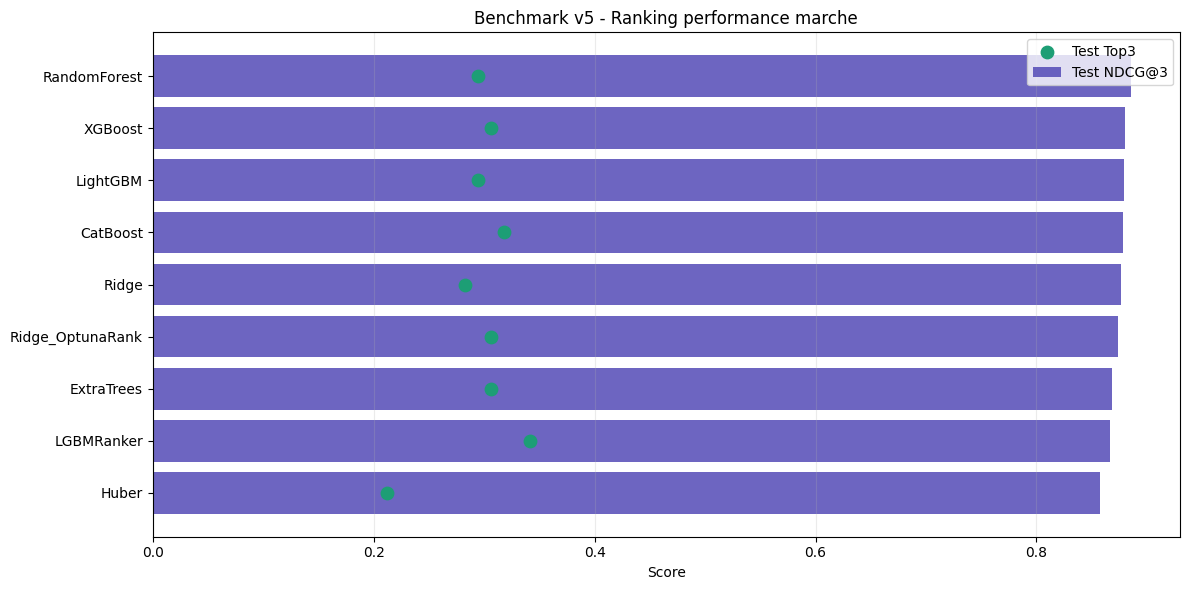

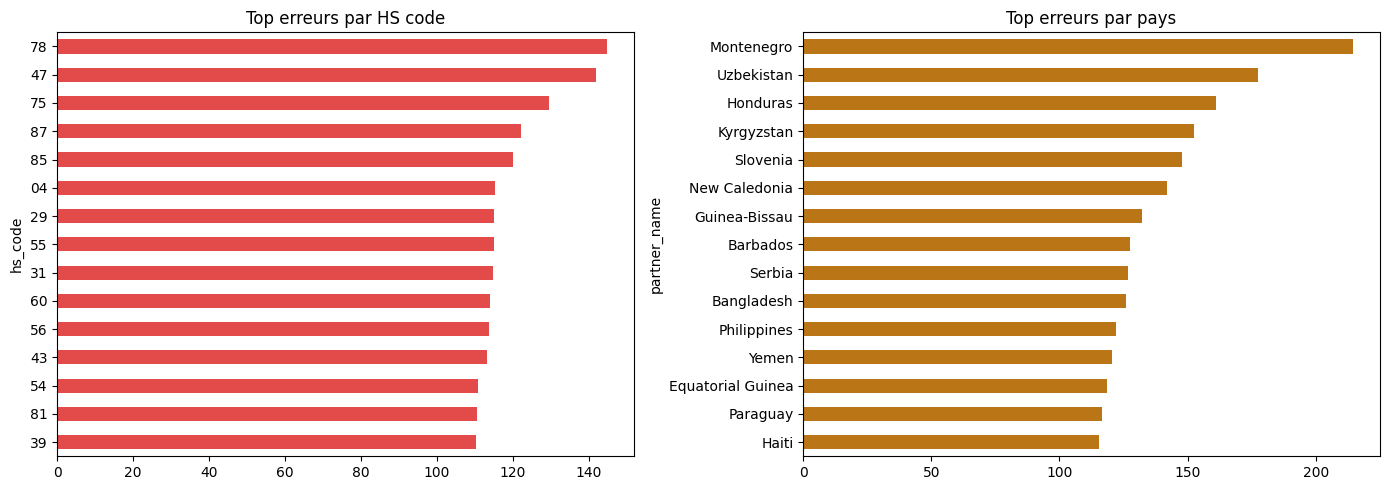

Worst predictions:


,hs_code,partner_name,year,y_true,y_pred,abs_error
15596,47,South Africa,2023,199.704127,-53.236644,252.940770
21915,68,Luxembourg,2023,-195.587534,53.791866,249.379400
2996,12,Cabo Verde,2023,-189.468858,40.843411,230.312269
10849,32,Austria,2023,-194.631606,34.438854,229.070461
12160,34,Oman,2023,198.780632,-24.901034,223.681666
9533,28,South Africa,2023,192.106173,-29.749094,221.855267
11478,33,Oman,2023,196.407809,-22.573293,218.981102
19139,61,Mauritania,2023,198.853245,-20.105615,218.958860
16423,49,Spain,2023,197.538226,-20.793574,218.331800
5524,17,Jordan,2023,191.619794,-25.377943,216.997737


In [8]:
summary = pd.DataFrame([
    {'model': n, **{f'val_{k}': v for k, v in r['val'].items() if k != 'groups'}, **{f'test_{k}': v for k, v in r['test'].items() if k != 'groups'}, 'business_score': business_score(r['val'])}
    for n, r in RESULTS.items()
]).sort_values(['business_score', 'test_ndcg@3'], ascending=False)

BEST_BUSINESS_MODEL = summary.iloc[0]['model']
print('BEST_BUSINESS_MODEL =', BEST_BUSINESS_MODEL)
print(summary[['model','business_score','val_top3_hit_rate','test_top3_hit_rate','test_ndcg@3','test_mean_regret','test_rmse','test_mae','test_spearman','test_r2']])

fig, ax = plt.subplots(figsize=(12, 6))
plot_df = summary.sort_values('test_ndcg@3', ascending=True)
ax.barh(plot_df['model'], plot_df['test_ndcg@3'], color='#534AB7', alpha=0.85, label='Test NDCG@3')
ax.scatter(plot_df['test_top3_hit_rate'], plot_df['model'], color='#1D9E75', s=80, label='Test Top3')
ax.set_title('Benchmark v5 - Ranking performance marche')
ax.set_xlabel('Score')
ax.grid(axis='x', alpha=0.25)
ax.legend()
plt.tight_layout()
safe_savefig('v5_model_ranking_comparison.png')
plt.show()

pred_best = RESULTS[BEST_BUSINESS_MODEL]['pred_test']
error_df = meta_te.copy()
error_df['y_true'] = y_te
error_df['y_pred'] = pred_best
error_df['abs_error'] = np.abs(error_df['y_true'] - error_df['y_pred'])
error_df['signed_error'] = error_df['y_true'] - error_df['y_pred']
error_by_hs = error_df.groupby('hs_code')['abs_error'].agg(['mean','median','count']).sort_values('mean', ascending=False)
error_by_country = error_df.groupby('partner_name')['abs_error'].agg(['mean','median','count']).sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
error_by_hs.head(15)['mean'].sort_values().plot(kind='barh', ax=axes[0], color='#E24B4A')
axes[0].set_title('Top erreurs par HS code')
error_by_country.head(15)['mean'].sort_values().plot(kind='barh', ax=axes[1], color='#BA7517')
axes[1].set_title('Top erreurs par pays')
plt.tight_layout()
safe_savefig('v5_error_analysis.png')
plt.show()

print('Worst predictions:')
error_df.sort_values('abs_error', ascending=False)[['hs_code','partner_name','year','y_true','y_pred','abs_error']].head(20)

## 8. Importance variables et sauvegarde artefact final

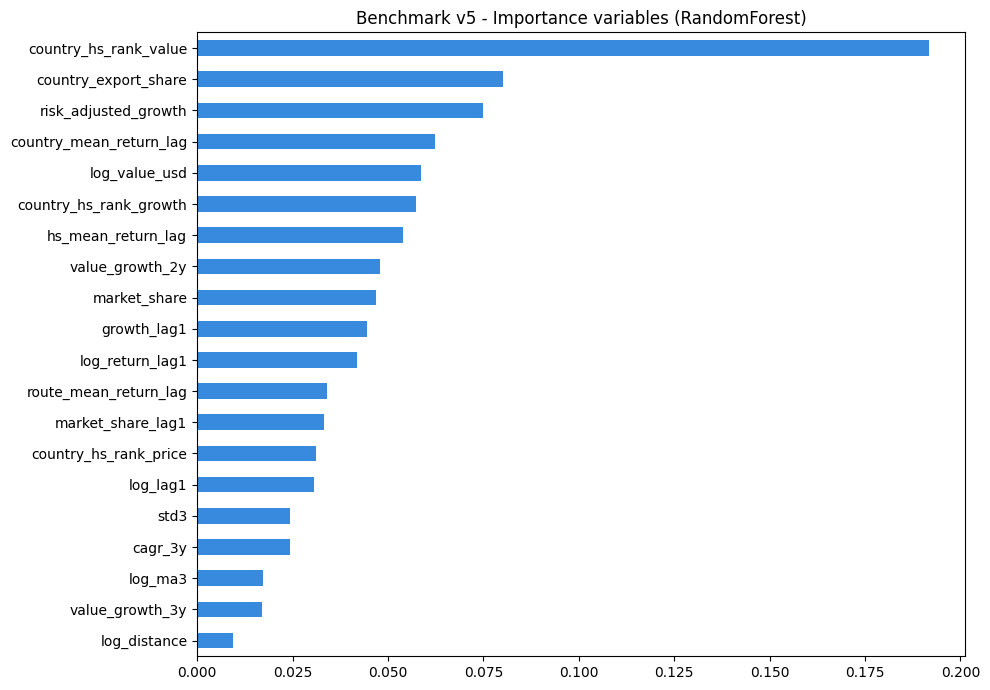

country_hs_rank_value      0.191696
country_export_share       0.080218
risk_adjusted_growth       0.074972
country_mean_return_lag    0.062422
log_value_usd              0.058568
country_hs_rank_growth     0.057370
hs_mean_return_lag         0.053886
value_growth_2y            0.047898
market_share               0.046789
growth_lag1                0.044554
log_return_lag1            0.041974
route_mean_return_lag      0.033915
market_share_lag1          0.033272
country_hs_rank_price      0.031031
log_lag1                   0.030687
std3                       0.024258
cagr_3y                    0.024255
log_ma3                    0.017202
value_growth_3y            0.016991
log_distance               0.009444
distance_km                0.007422
wb_gdp_per_capita          0.004218
wb_trade_pct_gdp           0.002272
wb_imports_pct_gdp         0.001688
access_score               0.001502
dtype: float64
Saved: C:\Users\HP\Desktop\MaroTrade Intelligence\artifacts\market_ranking_model_v5.j

In [9]:
best_model = FITTED[BEST_BUSINESS_MODEL]
importance = None
if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
elif hasattr(best_model, 'coef_'):
    importance = pd.Series(np.abs(best_model.coef_), index=FEATURES).sort_values(ascending=False)

if importance is not None:
    fig, ax = plt.subplots(figsize=(10, 7))
    importance.head(20).sort_values().plot(kind='barh', ax=ax, color='#378ADD')
    ax.set_title(f'Benchmark v5 - Importance variables ({BEST_BUSINESS_MODEL})')
    plt.tight_layout()
    safe_savefig('v5_feature_importance.png')
    plt.show()
    print(importance.head(25))

artifact = {
    'version': 'benchmark_phase1_v5',
    'objective': 'market_ranking_for_moroccan_smes',
    'best_business_model': str(BEST_BUSINESS_MODEL),
    'selection_metric': 'business_score=0.40*Top3+0.35*NDCG@3+0.15*Spearman-0.10*Regret/100 on validation',
    'features': FEATURES,
    'data_audit': audit,
    'split': {'train_year_max': int(train['year'].max()), 'val_years': [int(x) for x in val_years], 'test_feature_year': int(latest_feature_year), 'test_target_year': int(latest_feature_year + 1)},
    'results': {name: {'val': r['val'], 'test': r['test'], 'time': None if pd.isna(r['time']) else float(r['time'])} for name, r in RESULTS.items()},
    'optuna': OPTUNA_RESULTS,
    'figures_dir': str(FIGURES_DIR),
}

with open(ARTIFACTS_DIR / 'benchmark_phase1_v5_results.json', 'w', encoding='utf-8') as f:
    json.dump(artifact, f, ensure_ascii=False, indent=2)

if joblib is not None:
    joblib.dump({
        'model': best_model,
        'scaler': scaler,
        'medians': medians,
        'features': FEATURES,
        'metadata': artifact,
    }, ARTIFACTS_DIR / 'market_ranking_model_v5.joblib')
    print('Saved:', ARTIFACTS_DIR / 'market_ranking_model_v5.joblib')

print('Saved:', ARTIFACTS_DIR / 'benchmark_phase1_v5_results.json')
print('Figures:', sorted([p.name for p in FIGURES_DIR.glob('v5_*.png')]))